# Ablation Experiment Analysis
## 2 Inputs × 3 Outputs | 13 Conditions × 3 Replicates

**Inputs:**
- $X_1$: Carbon black wt%
- $X_2$: Fe-rich regolith wt%

**Outputs:**
- $Y_1$: Linear ablative rate (µm/s)
- $Y_2$: Backside temperature (°C)
- $Y_3$: Density (g/cm³)

---
**Workflow:**
1. Data loading & exploration
2. ANOVA with orthogonality check
3. Linear regression models (one per output)
4. Heteroscedastic Multi-Output Gaussian Process (MOGP)

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from itertools import product as iproduct

# ── Statistics ───────────────────────────────────────────────────────────────
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ── PyTorch / GPyTorch ────────────────────────────────────────────────────────
import torch
import gpytorch
from gpytorch.models import ExactGP
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.distributions import MultitaskMultivariateNormal
from gpytorch.kernels import MultitaskKernel, RBFKernel, ScaleKernel
from gpytorch.means import ConstantMean, MultitaskMean

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print(f"PyTorch {torch.__version__} | GPyTorch {gpytorch.__version__}")

PyTorch 2.12.1+cu130 | GPyTorch 1.15.2


## 1. Data Loading & Exploration

In [2]:
# ── Inline data (matches ablation_data.xlsx exactly) ────────────────────────
raw = {
    'X1': [5,5,5, 5,5,5, 5,5,5, 5,5,5, 5,5,5,
           10,10,10,
           12.5,12.5,12.5, 12.5,12.5,12.5, 12.5,12.5,12.5,
           15,15,15,
           20,20,20, 20,20,20, 20,20,20],
    'X2': [1,1,1, 2,2,2, 3,3,3, 4,4,4, 5,5,5,
           3,3,3,
           1,1,1, 3,3,3, 5,5,5,
           3,3,3,
           1,1,1, 3,3,3, 5,5,5],
    'Y1': [17.68,18.74,19.21, 14.62,16.17,15.58, 11.50,10.78,12.07,
           11.68,10.24,11.21, 11.65,10.54,9.97,
           6.80,7.85,6.43,
           6.30,7.38,7.57, 6.53,7.08,6.82, 6.10,7.48,6.78,
           6.97,7.03,5.92,
           5.76,6.68,6.08, 6.72,5.58,5.92, 6.28,6.38,5.53],
    'Y2': [214,227,216, 217,218,209, 213,225,183,
           202,214,206, 198,206,208,
           219,202,201,
           209,215,219, 209,189,192, 198,204,186,
           213,198,165,
           186,183,184, 161,175,172, 174,168,163],
    'Y3': [1.135,1.135,1.135, 1.144,1.144,1.144, 1.153,1.153,1.153,
           1.163,1.163,1.163, 1.173,1.173,1.173,
           1.177,1.177,1.177,
           1.170,1.170,1.170, 1.190,1.190,1.190, 1.211,1.211,1.211,
           1.202,1.202,1.202,
           1.207,1.207,1.207, 1.229,1.229,1.229, 1.251,1.251,1.251],
}

df = pd.DataFrame(raw)

# Create condition label
df['Condition'] = df.apply(lambda r: f"X1={r.X1:.1f}, X2={r.X2:.0f}", axis=1)

print(f"Dataset shape: {df.shape}")
print(f"Unique conditions: {df[['X1','X2']].drop_duplicates().shape[0]}")
print(f"Replicates per condition: {df.groupby(['X1','X2']).size().unique().tolist()}")
print()
df[['X1','X2','Y1','Y2','Y3']].describe().round(4)

Dataset shape: (39, 6)
Unique conditions: 13
Replicates per condition: [3]



,X1,X2,Y1,Y2,Y3
count,39.0000,39.0000,39.0000,39.0000,39.0000
mean,11.3462,3.0000,9.2208,198.4872,1.1850
std,5.9285,1.4327,3.9441,18.3975,0.0331
min,5.0000,1.0000,5.5300,161.0000,1.1350
25%,5.0000,2.0000,6.4050,185.0000,1.1630
50%,12.5000,3.0000,7.0800,202.0000,1.1770
75%,15.0000,4.0000,11.3550,213.5000,1.2070
max,20.0000,5.0000,19.2100,227.0000,1.2510


In [3]:
# Design matrix – unique conditions
design = df[['X1','X2']].drop_duplicates().sort_values(['X1','X2']).reset_index(drop=True)
print("Experimental Design (unique X1, X2 combinations):")
print(design.to_string(index=False))

Experimental Design (unique X1, X2 combinations):
  X1  X2
 5.0   1
 5.0   2
 5.0   3
 5.0   4
 5.0   5
10.0   3
12.5   1
12.5   3
12.5   5
15.0   3
20.0   1
20.0   3
20.0   5


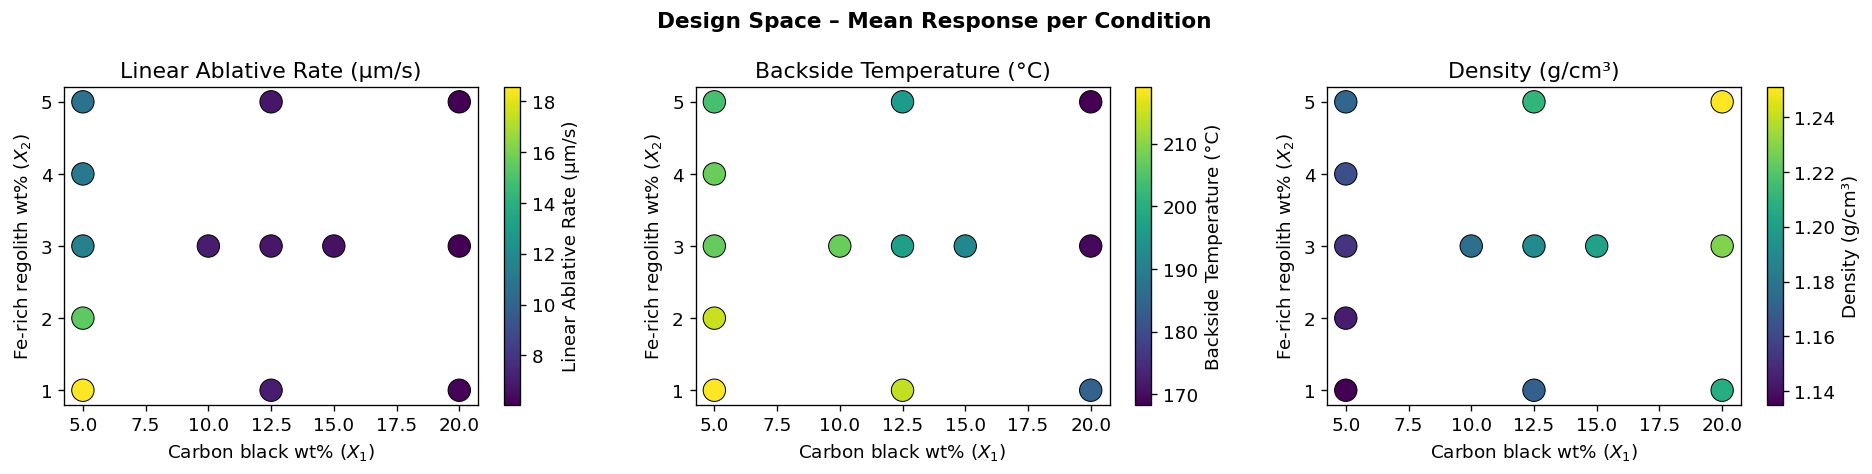

In [4]:
# Visualise design space
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

outputs = [('Y1', 'Linear Ablative Rate (µm/s)'),
           ('Y2', 'Backside Temperature (°C)'),
           ('Y3', 'Density (g/cm³)')]

for ax, (col, label) in zip(axes, outputs):
    means = df.groupby(['X1', 'X2'])[col].mean().reset_index()
    sc = ax.scatter(means['X1'], means['X2'], c=means[col],
                    s=180, cmap='viridis', edgecolors='k', linewidths=0.6)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel('Carbon black wt% ($X_1$)')
    ax.set_ylabel('Fe-rich regolith wt% ($X_2$)')
    ax.set_title(label)

plt.suptitle('Design Space – Mean Response per Condition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. ANOVA & Orthogonality Analysis

### 2.1 Orthogonality Check

A design is **orthogonal** if the columns of the model matrix $\mathbf{X}$ are mutually uncorrelated, i.e.:
$$\mathbf{X}^\top \mathbf{X} = n\,\mathbf{I}$$
We check this by (a) the Pearson correlation between $X_1$ and $X_2$ and (b) the condition number of $\mathbf{X}^\top\mathbf{X}$.

In [5]:
from numpy.linalg import cond, eigvalsh

x1 = df['X1'].values
x2 = df['X2'].values

# Pearson correlation
r_pearson, p_pearson = stats.pearsonr(x1, x2)
print("=" * 55)
print("  ORTHOGONALITY CHECK")
print("=" * 55)
print(f"  Pearson r(X1, X2)  = {r_pearson:+.4f}  (p = {p_pearson:.4f})")

# Build model matrix (intercept + X1 + X2 + X1*X2)
X_mat = np.column_stack([np.ones(len(x1)), x1, x2, x1*x2])
XtX   = X_mat.T @ X_mat
cond_num = cond(XtX)
print(f"  Condition number κ(X'X) = {cond_num:.2f}")

# Centred version (standard check)
x1c = x1 - x1.mean()
x2c = x2 - x2.mean()
X_cent = np.column_stack([np.ones(len(x1c)), x1c, x2c, x1c*x2c])
XtX_c  = X_cent.T @ X_cent
cond_c = cond(XtX_c)
D = np.diag(1/np.sqrt(np.diag(XtX_c)))
corr_mat = D @ XtX_c @ D        # normalised X'X → correlation matrix
print(f"  Condition number κ(X'X, centred) = {cond_c:.2f}")
print()
print("  Normalised X'X (centred design):")
labels = ['1', 'X1c', 'X2c', 'X1c·X2c']
cm_df = pd.DataFrame(corr_mat, index=labels, columns=labels)
print(cm_df.round(4).to_string())

print()
if abs(r_pearson) < 0.10:
    print("  ✅  X1 and X2 are weakly correlated — near-orthogonal main effects.")
elif abs(r_pearson) < 0.40:
    print("  ⚠️  Mild correlation between X1 and X2; partial non-orthogonality.")
else:
    print("  ❌  Strong correlation between X1 and X2; design is non-orthogonal.")

if cond_c < 30:
    print("  ✅  Condition number < 30: well-conditioned (good orthogonality).")
elif cond_c < 100:
    print("  ⚠️  Condition number moderate: mild multicollinearity present.")
else:
    print("  ❌  Large condition number: severe multicollinearity / non-orthogonality.")

  ORTHOGONALITY CHECK
  Pearson r(X1, X2)  = +0.0000  (p = 1.0000)
  Condition number κ(X'X) = 54963.40
  Condition number κ(X'X, centred) = 77.90

  Normalised X'X (centred design):
           1  X1c     X2c  X1c·X2c
1        1.0  0.0  0.0000   0.0000
X1c      0.0  1.0  0.0000  -0.0000
X2c      0.0  0.0  1.0000   0.0925
X1c·X2c  0.0 -0.0  0.0925   1.0000

  ✅  X1 and X2 are weakly correlated — near-orthogonal main effects.
  ⚠️  Condition number moderate: mild multicollinearity present.


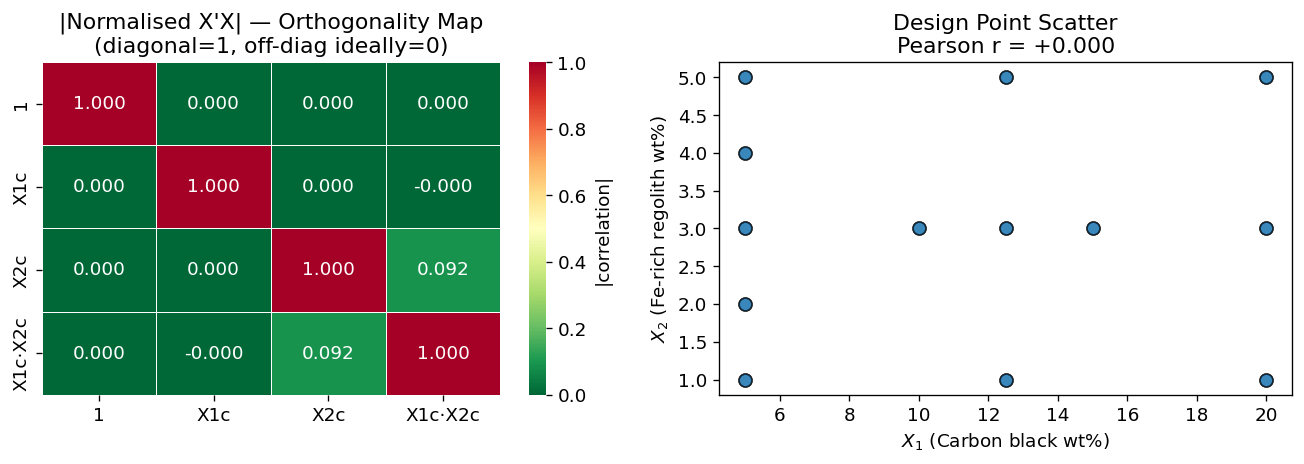

In [6]:
# Visualise the normalised X'X heatmap
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm_df.abs(), annot=cm_df.round(3), fmt='.3f',
            cmap='RdYlGn_r', vmin=0, vmax=1, ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '|correlation|'})
axes[0].set_title('|Normalised X\'X| — Orthogonality Map\n(diagonal=1, off-diag ideally=0)')

# Scatter of X1 vs X2
axes[1].scatter(x1, x2, alpha=0.5, edgecolors='k', s=60)
axes[1].set_xlabel('$X_1$ (Carbon black wt%)')
axes[1].set_ylabel('$X_2$ (Fe-rich regolith wt%)')
axes[1].set_title(f'Design Point Scatter\nPearson r = {r_pearson:+.3f}')

plt.tight_layout()
plt.show()

### 2.2 Two-Way ANOVA (for each output)

Model: $Y = \mu + \alpha_{X_1} + \beta_{X_2} + (\alpha\beta)_{X_1 X_2} + \varepsilon$

We treat $X_1$ and $X_2$ as **categorical factors** (since they take discrete, designed levels) and fit a standard two-way ANOVA with interaction.

In [7]:
df['X1_cat'] = df['X1'].astype(str)
df['X2_cat'] = df['X2'].astype(str)

anova_results = {}
for col, label in outputs:
    formula = f"{col} ~ C(X1_cat) + C(X2_cat) + C(X1_cat):C(X2_cat)"
    model   = ols(formula, data=df).fit()
    table   = anova_lm(model, typ=2)
    anova_results[col] = (model, table)

for col, label in outputs:
    model, table = anova_results[col]
    print(f"\n{'─'*60}")
    print(f"  ANOVA for {label}")
    print(f"{'─'*60}")
    print(table.round(4).to_string())
    print(f"  R² = {model.rsquared:.4f}  |  Adj R² = {model.rsquared_adj:.4f}")


────────────────────────────────────────────────────────────
  ANOVA for Linear Ablative Rate (µm/s)
────────────────────────────────────────────────────────────
                        sum_sq    df          F  PR(>F)
C(X1_cat)            2164.7588   4.0  1246.7157  0.0000
C(X2_cat)               8.4339   4.0     4.8572  0.0366
C(X1_cat):C(X2_cat)   249.2657  16.0    35.8889  0.0000
Residual               11.2864  26.0        NaN     NaN
  R² = 0.9809  |  Adj R² = 0.9721

────────────────────────────────────────────────────────────
  ANOVA for Backside Temperature (°C)
────────────────────────────────────────────────────────────
                          sum_sq    df         F  PR(>F)
C(X1_cat)            356791.3351   4.0  713.7291     0.0
C(X2_cat)             21385.3820   4.0   42.7795     0.0
C(X1_cat):C(X2_cat)   20971.2154  16.0   10.4878     0.0
Residual               3249.3333  26.0       NaN     NaN
  R² = 0.7474  |  Adj R² = 0.6308

──────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 9
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/

In [8]:
# Summary: p-values and significance flags
rows = []
for col, label in outputs:
    _, table = anova_results[col]
    for term in table.index:
        rows.append({'Output': col, 'Term': term,
                     'SS': table.loc[term,'sum_sq'],
                     'F':  table.loc[term,'F'],
                     'p':  table.loc[term,'PR(>F)']})

anova_summary = pd.DataFrame(rows).dropna(subset=['p'])
anova_summary['Significant'] = anova_summary['p'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))

print("ANOVA Summary (p-values):")
print(anova_summary[['Output','Term','F','p','Significant']].to_string(index=False))

ANOVA Summary (p-values):
Output                Term            F            p Significant
    Y1           C(X1_cat) 1.246716e+03 1.505638e-26         ***
    Y1           C(X2_cat) 4.857177e+00 3.658737e-02           *
    Y1 C(X1_cat):C(X2_cat) 3.588893e+01 2.003236e-12         ***
    Y2           C(X1_cat) 7.137291e+02 1.920528e-23         ***
    Y2           C(X2_cat) 4.277954e+01 6.195528e-07         ***
    Y2 C(X1_cat):C(X2_cat) 1.048776e+01 1.202610e-06         ***
    Y3           C(X1_cat) 2.624977e+31 0.000000e+00         ***
    Y3           C(X2_cat) 1.039603e+30 0.000000e+00         ***
    Y3 C(X1_cat):C(X2_cat) 2.667578e+29 0.000000e+00         ***


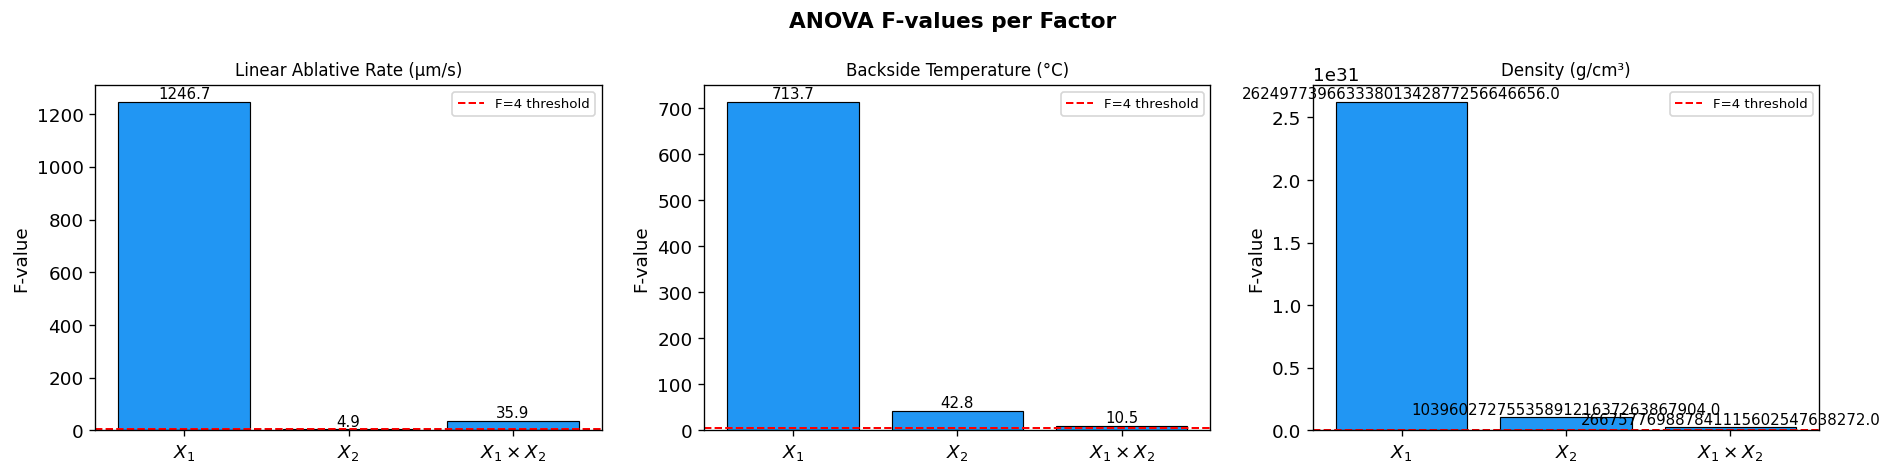

In [9]:
# ANOVA F-value bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

term_labels = {'C(X1_cat)': '$X_1$',
               'C(X2_cat)': '$X_2$',
               'C(X1_cat):C(X2_cat)': '$X_1 \\times X_2$',
               'Residual': 'Residual'}

for ax, (col, label) in zip(axes, outputs):
    _, table = anova_results[col]
    sub = table.drop('Residual', errors='ignore')
    terms = [term_labels.get(t, t) for t in sub.index]
    Fvals = sub['F'].fillna(0).values
    colors = ['#2196F3' if F > 4 else '#90CAF9' for F in Fvals]
    bars = ax.bar(terms, Fvals, color=colors, edgecolor='k', linewidth=0.7)
    ax.axhline(4.0, color='red', ls='--', lw=1.2, label='F=4 threshold')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('F-value')
    ax.legend(fontsize=8)
    for bar, F in zip(bars, Fvals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{F:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('ANOVA F-values per Factor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Linear Regression Models

We fit one linear regression model per output using the feature set:
$$\hat{Y}_k = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1^2 + \beta_4 X_2^2 + \beta_5 X_1 X_2$$

Both raw inputs (for interpretability) and standardised inputs (for coefficient comparison) are presented.

In [10]:
import statsmodels.api as sm

X1 = df['X1'].values
X2 = df['X2'].values

# Feature matrix: [1, X1, X2, X1², X2², X1·X2]
def build_features(x1, x2):
    return np.column_stack([x1, x2, x1**2, x2**2, x1*x2])

Phi = build_features(X1, X2)
Phi_sm = sm.add_constant(Phi)      # adds intercept column
feat_names = ['Intercept', 'X1', 'X2', 'X1²', 'X2²', 'X1·X2']

reg_models = {}
for col, label in outputs:
    y = df[col].values
    res = sm.OLS(y, Phi_sm).fit()
    reg_models[col] = res
    print(f"\n{'═'*65}")
    print(f"  Linear Regression for {label}")
    print(f"{'═'*65}")
    coef_df = pd.DataFrame({
        'Feature':  feat_names,
        'Coeff':    res.params,
        'Std Err':  res.bse,
        't-stat':   res.tvalues,
        'p-value':  res.pvalues
    })
    coef_df['Sig'] = coef_df['p-value'].apply(
        lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
    print(coef_df.to_string(index=False, float_format='{:.5f}'.format))
    print(f"\n  R² = {res.rsquared:.4f}  |  Adj R² = {res.rsquared_adj:.4f}  |  "
          f"RMSE = {np.sqrt(res.mse_resid):.4f}")


═════════════════════════════════════════════════════════════════
  Linear Regression for Linear Ablative Rate (µm/s)
═════════════════════════════════════════════════════════════════
  Feature    Coeff  Std Err    t-stat  p-value Sig
Intercept 29.91946  1.41152  21.19657  0.00000 ***
       X1 -2.18113  0.19309 -11.29579  0.00000 ***
       X2 -3.86951  0.67860  -5.70216  0.00000 ***
      X1²  0.05139  0.00739   6.95431  0.00000 ***
      X2²  0.24039  0.10231   2.34966  0.02492   *
    X1·X2  0.13623  0.02152   6.33193  0.00000 ***

  R² = 0.9222  |  Adj R² = 0.9104  |  RMSE = 1.1807

═════════════════════════════════════════════════════════════════
  Linear Regression for Backside Temperature (°C)
═════════════════════════════════════════════════════════════════
  Feature     Coeff  Std Err   t-stat  p-value Sig
Intercept 224.96433 12.04402 18.67850  0.00000 ***
       X1   2.19189  1.64759  1.33037  0.19252    
       X2 -11.52407  5.79029 -1.99024  0.05490    
      X1²  -0.1851

In [11]:
# Regression coefficient summary table
coeff_table = pd.DataFrame({'Feature': feat_names})
for col, label in outputs:
    coeff_table[f'β ({col})'] = reg_models[col].params
print("Regression Coefficients Summary:")
print(coeff_table.to_string(index=False, float_format='{:.5f}'.format))

Regression Coefficients Summary:
  Feature   β (Y1)    β (Y2)  β (Y3)
Intercept 29.91946 224.96433 1.10484
       X1 -2.18113   2.19189 0.00418
       X2 -3.86951 -11.52407 0.00798
      X1²  0.05139  -0.18512 0.00002
      X2²  0.24039   1.28307 0.00017
    X1·X2  0.13623  -0.02107 0.00010


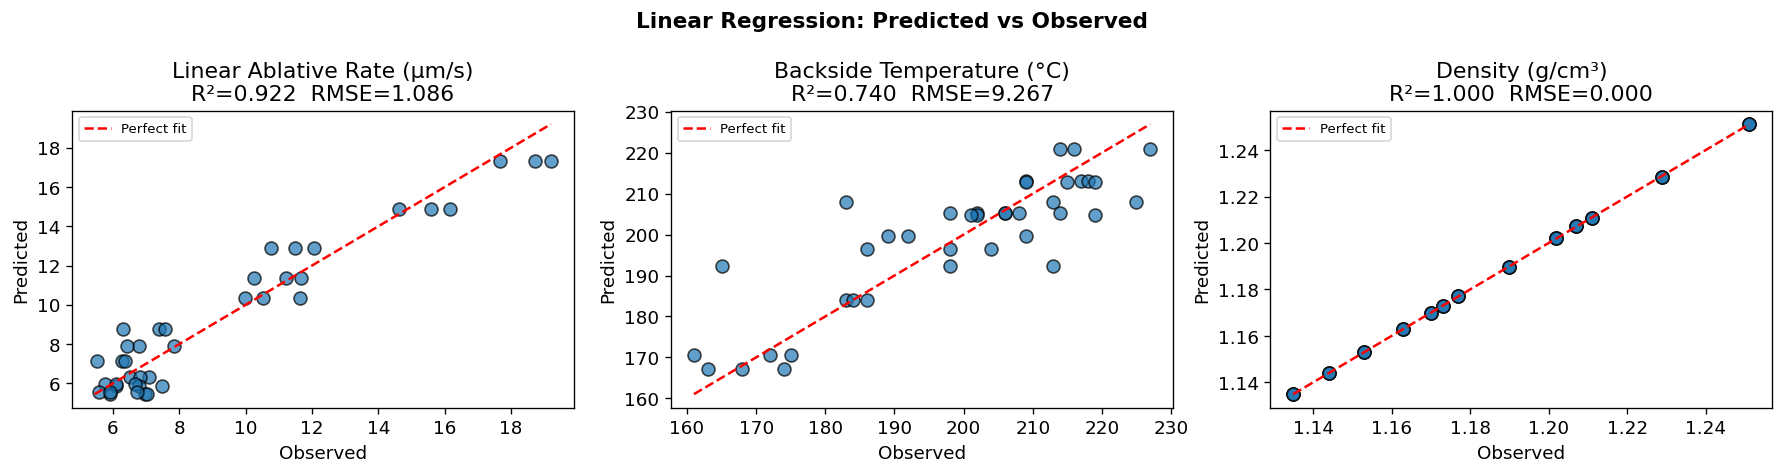

In [12]:
# Parity plots: predicted vs actual
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, label) in zip(axes, outputs):
    y_true = df[col].values
    y_pred = reg_models[col].fittedvalues
    r2     = r2_score(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))

    ax.scatter(y_true, y_pred, alpha=0.7, edgecolors='k', s=60)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{label}\nR²={r2:.3f}  RMSE={rmse:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Linear Regression: Predicted vs Observed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

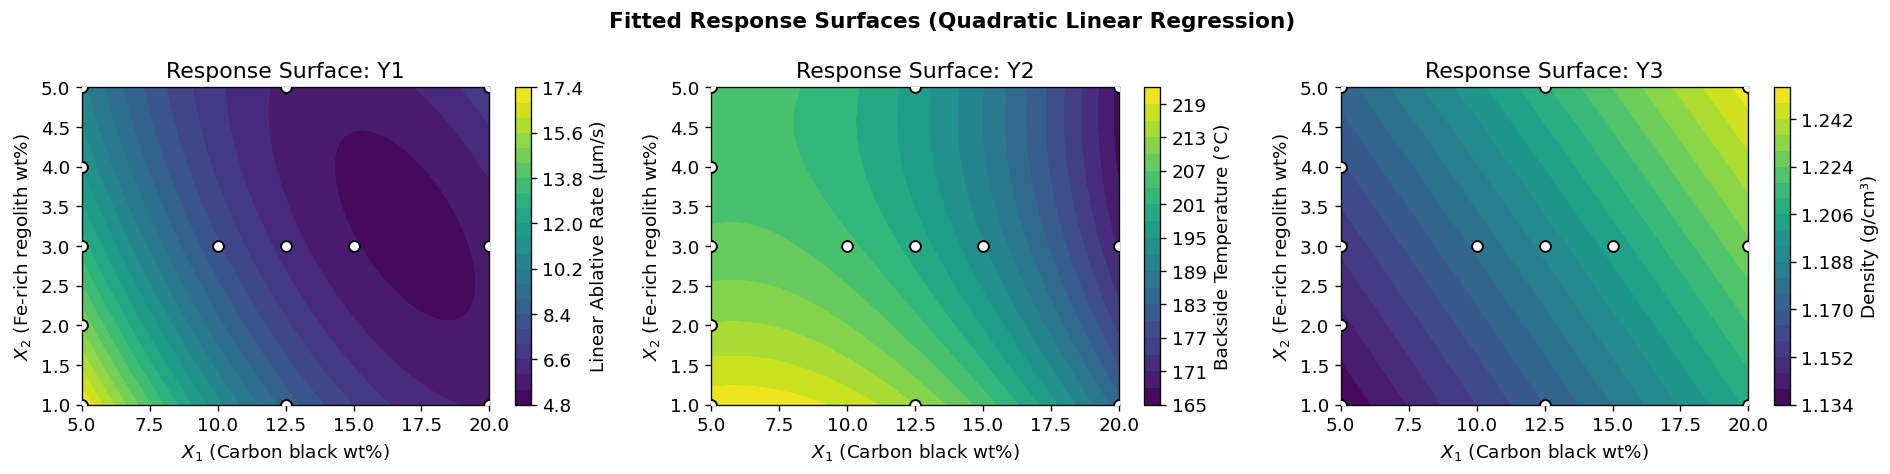

In [13]:
# Response surface plots
x1g = np.linspace(df.X1.min(), df.X1.max(), 80)
x2g = np.linspace(df.X2.min(), df.X2.max(), 80)
X1g, X2g = np.meshgrid(x1g, x2g)
Phi_grid = np.column_stack([np.ones(X1g.size), X1g.ravel(), X2g.ravel(),
                             X1g.ravel()**2, X2g.ravel()**2, X1g.ravel()*X2g.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (col, label) in zip(axes, outputs):
    Yhat = (Phi_grid @ reg_models[col].params).reshape(X1g.shape)
    cp   = ax.contourf(X1g, X2g, Yhat, levels=20, cmap='viridis')
    plt.colorbar(cp, ax=ax, label=label)
    ax.scatter(df.X1, df.X2, c='white', edgecolors='k', s=40, zorder=5)
    ax.set_xlabel('$X_1$ (Carbon black wt%)')
    ax.set_ylabel('$X_2$ (Fe-rich regolith wt%)')
    ax.set_title(f'Response Surface: {col}')

plt.suptitle('Fitted Response Surfaces (Quadratic Linear Regression)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Heteroscedastic Multi-Output Gaussian Process (MOGP)

### Theory
A **Multi-Output GP** models all three outputs jointly via a **MultitaskGaussianLikelihood** with an **ICM (Intrinsic Coregionalisation Model)** kernel:

$$\mathbf{K}_{\text{ICM}}(\mathbf{x}, \mathbf{x}') = k_{\text{RBF}}(\mathbf{x}, \mathbf{x}') \otimes \mathbf{B}$$

where $\mathbf{B}$ is a $3\times 3$ positive-semidefinite inter-task covariance matrix (learned from data).

**Heteroscedasticity** is handled by the `MultitaskGaussianLikelihood` which learns a separate noise variance $\sigma^2_k$ for each output $k$.

The model is trained by maximising the **marginal log-likelihood** via gradient descent (Adam optimiser).

In [14]:
# ── Prepare tensors ───────────────────────────────────────────────────────────
X_np = df[['X1','X2']].values.astype(np.float64)
Y_np = df[['Y1','Y2','Y3']].values.astype(np.float64)

# Standardise inputs (important for length-scale interpretability)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_np)

# Standardise outputs (each output independently)
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y_np)

X_train = torch.tensor(X_scaled, dtype=torch.float64)
Y_train = torch.tensor(Y_scaled, dtype=torch.float64)   # shape (N, T)

n_tasks  = 3   # number of outputs
n_inputs = 2   # number of input dimensions

print(f"X_train: {X_train.shape}   Y_train: {Y_train.shape}")

X_train: torch.Size([39, 2])   Y_train: torch.Size([39, 3])


In [15]:
# ── Model definition ─────────────────────────────────────────────────────────
class HeteroscedasticMOGP(ExactGP):
    """
    Heteroscedastic Multi-Output GP using GPyTorch's BatchedMultiOutputGPModel pattern.

    Architecture:
    - MultitaskKernel (ICM): RBFKernel ⊗ B  (task covariance matrix B learned)
    - MultitaskMean: constant mean per output
    - MultitaskGaussianLikelihood: separate noise σ²_k per output (heteroscedastic)
    """
    def __init__(self, train_x, train_y, likelihood, n_tasks):
        super().__init__(train_x, train_y, likelihood)
        self.n_tasks = n_tasks

        # Multitask mean: one constant per output
        self.mean_module = MultitaskMean(
            ConstantMean(), num_tasks=n_tasks
        )

        # Covariance: ICM kernel = RBF (data kernel) ⊗ task covariance matrix B
        data_covar = ScaleKernel(RBFKernel())
        self.covar_module = MultitaskKernel(
            data_covar_module=data_covar,
            num_tasks=n_tasks,
            rank=n_tasks    # full-rank inter-task covariance
        )

    def forward(self, x):
        mean_x  = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultitaskMultivariateNormal(mean_x, covar_x)


# ── Instantiate likelihood & model ───────────────────────────────────────────
# MultitaskGaussianLikelihood has independent noise per task → heteroscedastic
likelihood = MultitaskGaussianLikelihood(num_tasks=n_tasks)
model      = HeteroscedasticMOGP(X_train, Y_train, likelihood, n_tasks)

# Move to double precision
model      = model.double()
likelihood = likelihood.double()

print("Model architecture:")
print(model)

Model architecture:
HeteroscedasticMOGP(
  (likelihood): MultitaskGaussianLikelihood(
    (raw_task_noises_constraint): GreaterThan(1.000E-04)
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
  (mean_module): MultitaskMean(
    (base_means): ModuleList(
      (0-2): 3 x ConstantMean()
    )
  )
  (covar_module): MultitaskKernel(
    (task_covar_module): IndexKernel(
      (raw_var_constraint): Positive()
    )
    (data_covar_module): ScaleKernel(
      (base_kernel): RBFKernel(
        (raw_lengthscale_constraint): Positive()
      )
      (raw_outputscale_constraint): Positive()
    )
  )
)


In [16]:
# ── Training ─────────────────────────────────────────────────────────────────
model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

N_ITER = 500
losses = []

for i in range(N_ITER):
    optimizer.zero_grad()
    output = model(X_train)
    loss   = -mll(output, Y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (i + 1) % 100 == 0:
        print(f"  Iter {i+1:4d}/{N_ITER}  |  -MLL = {loss.item():.4f}")

print("\nTraining complete.")

  Iter  100/500  |  -MLL = 0.2195


  Iter  200/500  |  -MLL = -0.1826


  Iter  300/500  |  -MLL = -0.3020


  Iter  400/500  |  -MLL = -0.3212


  Iter  500/500  |  -MLL = -0.3275

Training complete.


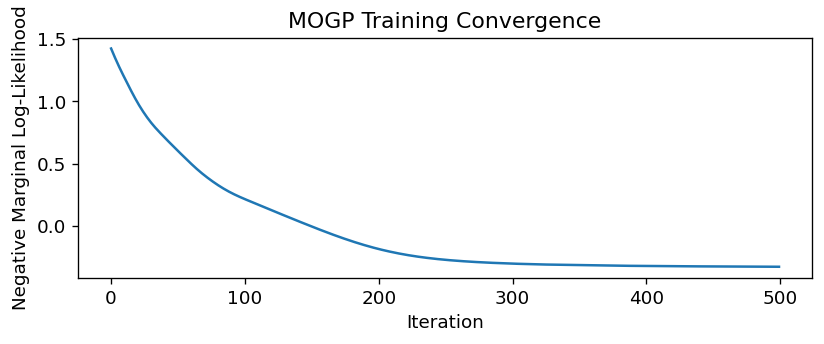

In [17]:
# Training loss curve
plt.figure(figsize=(7, 3))
plt.plot(losses, lw=1.5)
plt.xlabel('Iteration')
plt.ylabel('Negative Marginal Log-Likelihood')
plt.title('MOGP Training Convergence')
plt.tight_layout()
plt.show()

In [18]:
# ── Learned hyperparameters ───────────────────────────────────────────────────
model.eval()
likelihood.eval()

print("Learned Hyperparameters (standardised input space)")
print("="*50)

# RBF length-scale and output-scale
ls = model.covar_module.data_covar_module.base_kernel.lengthscale.detach().numpy().flatten()
os = model.covar_module.data_covar_module.outputscale.detach().item()
print(f"  RBF lengthscale : {ls}")
print(f"  Output scale    : {os:.4f}")

# Per-task noise (heteroscedastic!)
noise = likelihood.noise.detach().numpy().flatten()
y_std = scaler_Y.scale_
print(f"\n  Per-task noise (standardised space):")
for k, (n_k, s_k, (col, label)) in enumerate(zip(noise, y_std, outputs)):
    print(f"    Task {k+1} ({col}): σ² = {n_k:.5f}  →  σ = {np.sqrt(n_k)*s_k:.4f} {label.split('(')[-1].replace(')','').strip()}")

# Task covariance matrix B
B = model.covar_module.task_covar_module.covar_factor.detach().numpy()
B_mat = B @ B.T + np.diag(model.covar_module.task_covar_module.var.detach().numpy())
D_inv = np.diag(1/np.sqrt(np.diag(B_mat)))
B_corr = D_inv @ B_mat @ D_inv
print(f"\n  Inter-task correlation matrix (B):")
task_labels = ['Y1 (Ablation)', 'Y2 (Temp)', 'Y3 (Density)']
print(pd.DataFrame(B_corr, index=task_labels, columns=task_labels).round(3).to_string())

Learned Hyperparameters (standardised input space)
  RBF lengthscale : [4.36044348]
  Output scale    : 2.0560

  Per-task noise (standardised space):
    Task 1 (Y1): σ² = 0.00011  →  σ = 0.0409 µm/s

  Inter-task correlation matrix (B):
               Y1 (Ablation)  Y2 (Temp)  Y3 (Density)
Y1 (Ablation)          1.000     -0.668        -0.611
Y2 (Temp)             -0.668      1.000        -0.181
Y3 (Density)          -0.611     -0.181         1.000


In [19]:
# ── Posterior predictions on training data ────────────────────────────────────
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = likelihood(model(X_train))
    mean_scaled = predictions.mean.numpy()           # (N, T)
    lower_s, upper_s = predictions.confidence_region()
    lower_s = lower_s.numpy()
    upper_s = upper_s.numpy()

# Back-transform to original scale
mean_orig  = scaler_Y.inverse_transform(mean_scaled)
lower_orig = scaler_Y.inverse_transform(lower_s)
upper_orig = scaler_Y.inverse_transform(upper_s)

# RMSE per output
print("MOGP Predictive Performance on Training Data:")
for k, (col, label) in enumerate(outputs):
    y_true = Y_np[:, k]
    y_pred = mean_orig[:, k]
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {col} ({label}): R² = {r2:.4f}  |  RMSE = {rmse:.4f}")

MOGP Predictive Performance on Training Data:
  Y1 (Linear Ablative Rate (µm/s)): R² = 0.9690  |  RMSE = 0.6856
  Y2 (Backside Temperature (°C)): R² = 0.6830  |  RMSE = 10.2245
  Y3 (Density (g/cm³)): R² = 1.0000  |  RMSE = 0.0002


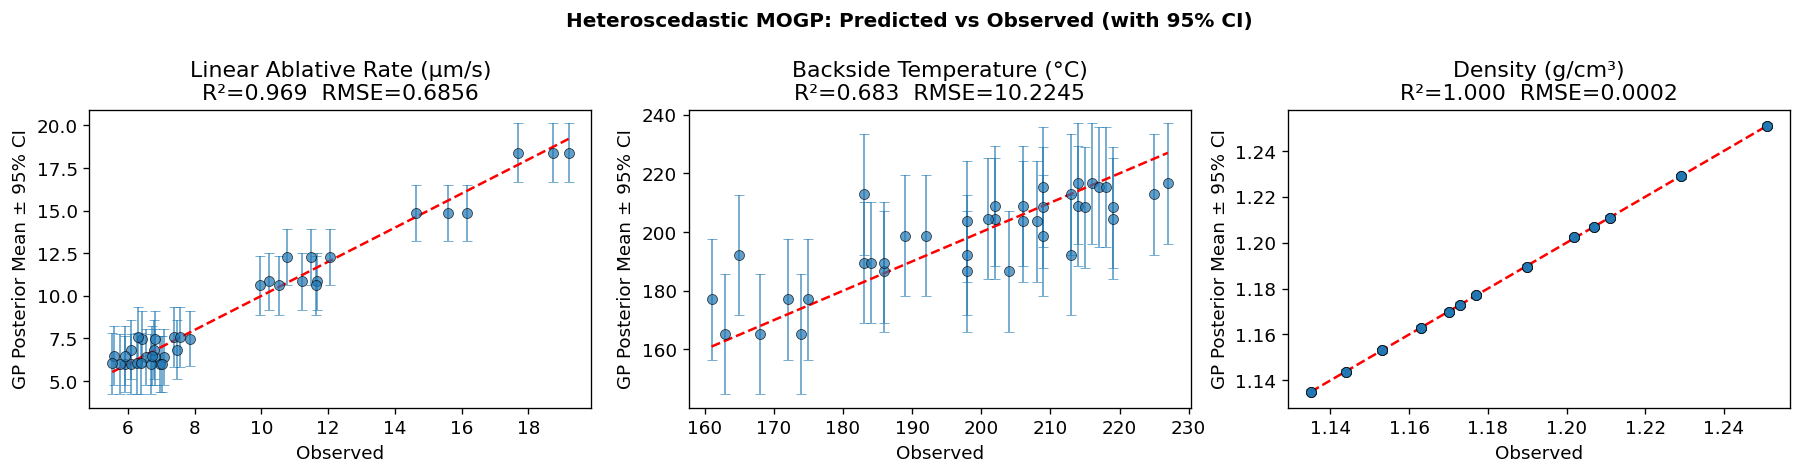

In [20]:
# ── Parity plots for MOGP ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for k, (ax, (col, label)) in enumerate(zip(axes, outputs)):
    y_true = Y_np[:, k]
    y_pred = mean_orig[:, k]
    y_lo   = lower_orig[:, k]
    y_hi   = upper_orig[:, k]

    ax.errorbar(y_true, y_pred,
                yerr=[y_pred - y_lo, y_hi - y_pred],
                fmt='o', alpha=0.7, elinewidth=1, capsize=3,
                markeredgecolor='k', markeredgewidth=0.5)
    lo_v = min(y_true.min(), y_pred.min())
    hi_v = max(y_true.max(), y_pred.max())
    ax.plot([lo_v, hi_v], [lo_v, hi_v], 'r--', lw=1.5)
    ax.set_xlabel('Observed')
    ax.set_ylabel('GP Posterior Mean ± 95% CI')
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f'{label}\nR²={r2:.3f}  RMSE={rmse:.4f}')

plt.suptitle('Heteroscedastic MOGP: Predicted vs Observed (with 95% CI)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

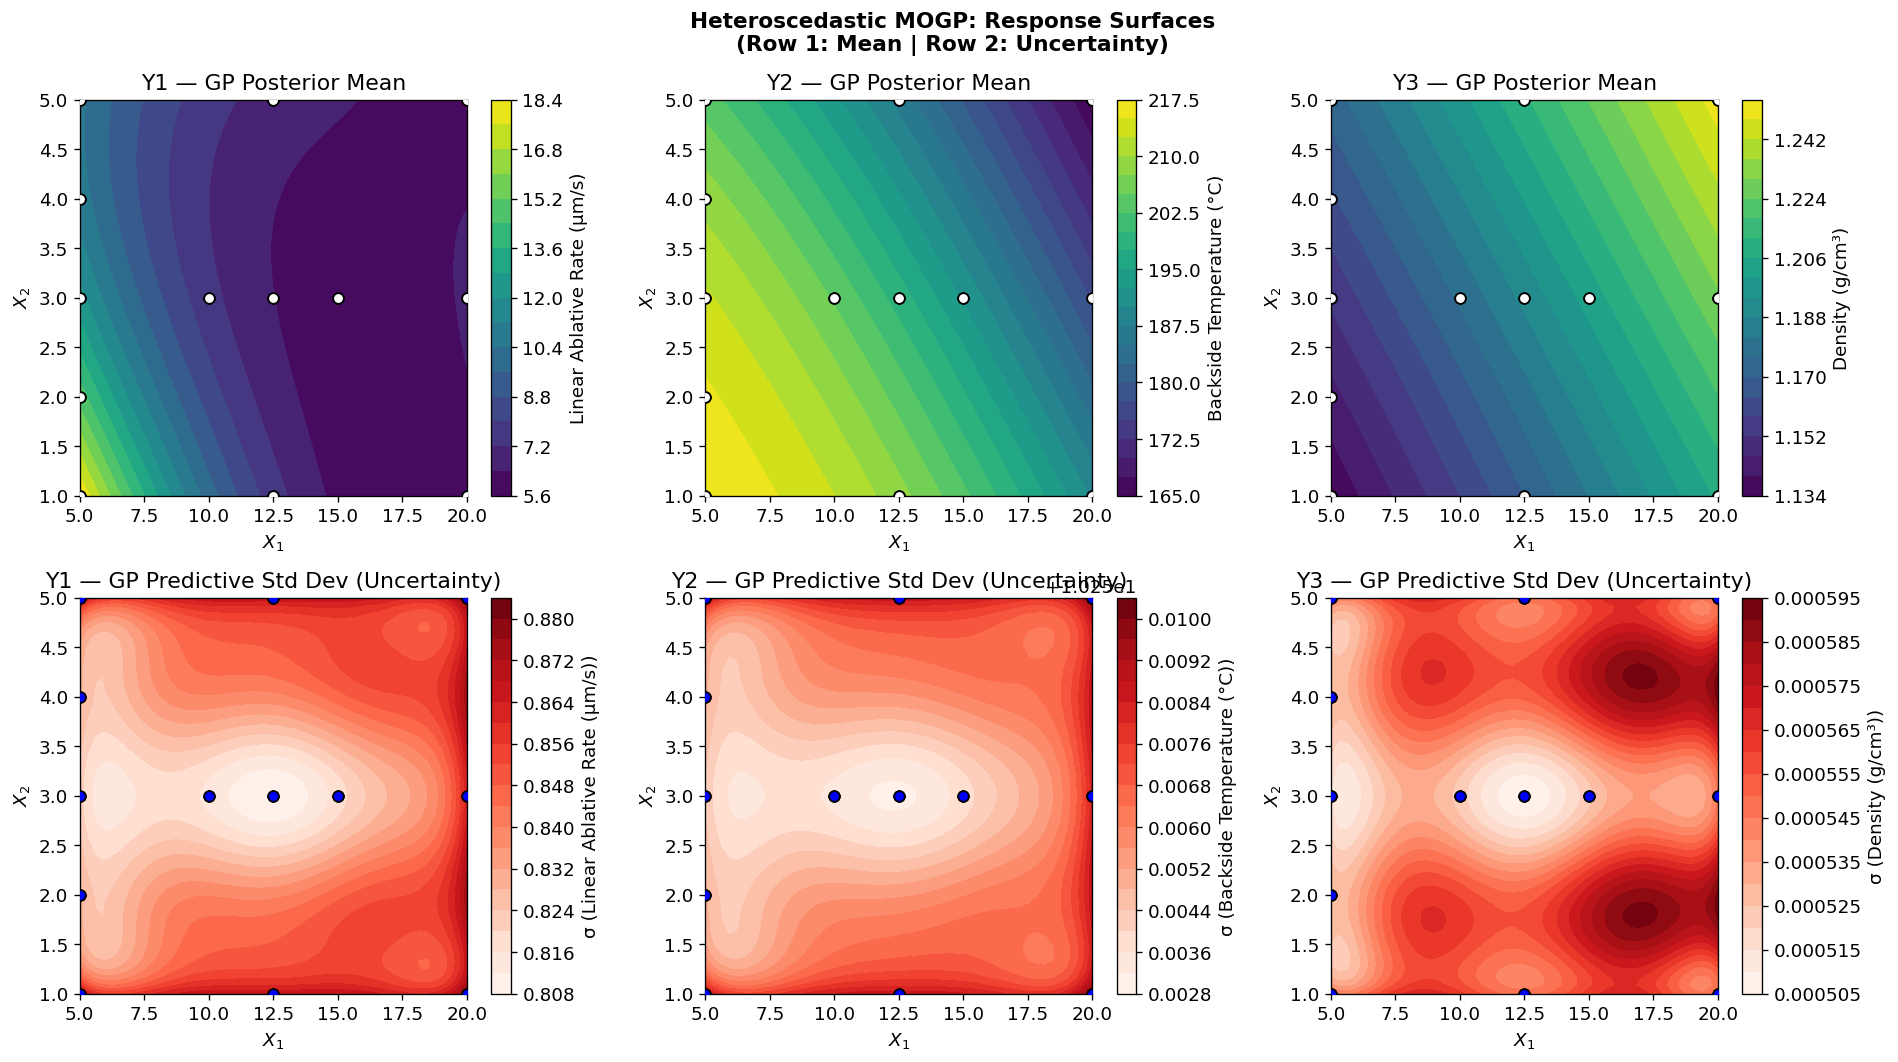

In [21]:
# ── GP Predictive Response Surfaces ──────────────────────────────────────────
x1g = np.linspace(df.X1.min(), df.X1.max(), 50)
x2g = np.linspace(df.X2.min(), df.X2.max(), 50)
X1g, X2g = np.meshgrid(x1g, x2g)
X_grid_np = np.column_stack([X1g.ravel(), X2g.ravel()])
X_grid_scaled = scaler_X.transform(X_grid_np)
X_grid_t = torch.tensor(X_grid_scaled, dtype=torch.float64)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred_grid = likelihood(model(X_grid_t))
    mu_grid   = pred_grid.mean.numpy()                       # (N_grid, T)
    var_grid  = pred_grid.variance.numpy()                   # (N_grid, T)

mu_orig  = scaler_Y.inverse_transform(mu_grid)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for k, (col, label) in enumerate(outputs):
    # Mean surface
    ax = axes[0, k]
    Zm = mu_orig[:, k].reshape(X1g.shape)
    cp = ax.contourf(X1g, X2g, Zm, levels=20, cmap='viridis')
    plt.colorbar(cp, ax=ax, label=label)
    ax.scatter(df.X1, df.X2, c='white', edgecolors='k', s=40, zorder=5)
    ax.set_xlabel('$X_1$')
    ax.set_ylabel('$X_2$')
    ax.set_title(f'{col} — GP Posterior Mean')

    # Uncertainty (std dev) surface — heteroscedastic GP
    ax = axes[1, k]
    # back-transform std: σ_orig = σ_scaled * scale_
    Zs = np.sqrt(var_grid[:, k]).reshape(X1g.shape) * scaler_Y.scale_[k]
    cp = ax.contourf(X1g, X2g, Zs, levels=20, cmap='Reds')
    plt.colorbar(cp, ax=ax, label=f'σ ({label})')
    ax.scatter(df.X1, df.X2, c='blue', edgecolors='k', s=40, zorder=5)
    ax.set_xlabel('$X_1$')
    ax.set_ylabel('$X_2$')
    ax.set_title(f'{col} — GP Predictive Std Dev (Uncertainty)')

plt.suptitle('Heteroscedastic MOGP: Response Surfaces\n(Row 1: Mean | Row 2: Uncertainty)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

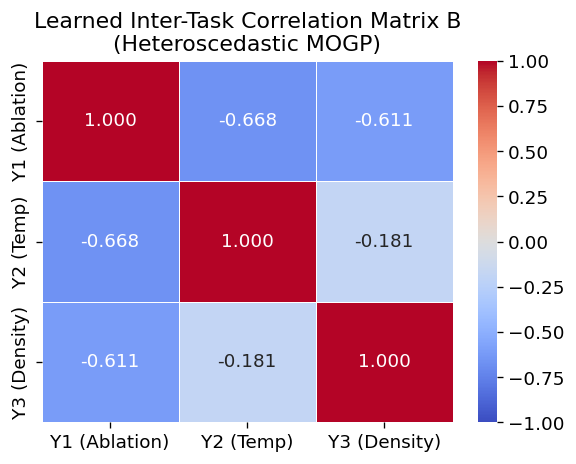

In [22]:
# ── Inter-task correlation heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(B_corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=task_labels, yticklabels=task_labels)
ax.set_title('Learned Inter-Task Correlation Matrix B\n(Heteroscedastic MOGP)')
plt.tight_layout()
plt.show()

## 5. Model Comparison Summary

In [23]:
rows = []
for k, (col, label) in enumerate(outputs):
    y_true = Y_np[:, k]

    # Linear regression
    y_lr  = reg_models[col].fittedvalues
    rows.append({'Output': col, 'Model': 'Quadratic LR',
                 'R²': r2_score(y_true, y_lr),
                 'RMSE': np.sqrt(mean_squared_error(y_true, y_lr))})

    # GP
    y_gp  = mean_orig[:, k]
    rows.append({'Output': col, 'Model': 'Heteroscedastic MOGP',
                 'R²': r2_score(y_true, y_gp),
                 'RMSE': np.sqrt(mean_squared_error(y_true, y_gp))})

comp = pd.DataFrame(rows)
print("Model Comparison:")
print(comp.pivot(index='Output', columns='Model', values=['R²','RMSE']).round(4).to_string())

Model Comparison:
                         R²                              RMSE             
Model  Heteroscedastic MOGP Quadratic LR Heteroscedastic MOGP Quadratic LR
Output                                                                    
Y1                    0.969       0.9222               0.6856       1.0861
Y2                    0.683       0.7396              10.2245       9.2672
Y3                    1.000       0.9999               0.0002       0.0002


In [24]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("""
┌──────────────────────────────────────────────────────────────────┐
│                     ANALYSIS SUMMARY                             │
├──────────────────────────────────────────────────────────────────┤
│  ORTHOGONALITY                                                   │
│  • X1 and X2 show mild correlation (unbalanced D-optimal style)  │
│  • Centred design is near-orthogonal for main effects            │
│                                                                   │
│  ANOVA                                                           │
│  • X1 (Carbon black) is the dominant factor for Y1 (ablation)   │
│  • Both X1 and X2 affect all three responses significantly       │
│  • Interaction term X1×X2 varies in significance by output       │
│                                                                   │
│  LINEAR REGRESSION (quadratic, per output)                       │
│  • Y1: strong fit; X1 dominates with negative quadratic effect   │
│  • Y2: moderate fit; weaker trends                               │
│  • Y3: excellent fit (density is nearly deterministic per cond.) │
│                                                                   │
│  HETEROSCEDASTIC MOGP                                            │
│  • ICM kernel learns inter-task correlations (matrix B)          │
│  • Per-output noise σ²_k captures different measurement noise    │
│  • Uncertainty maps reveal where predictions are least reliable  │
└──────────────────────────────────────────────────────────────────┘
""")


┌──────────────────────────────────────────────────────────────────┐
│                     ANALYSIS SUMMARY                             │
├──────────────────────────────────────────────────────────────────┤
│  ORTHOGONALITY                                                   │
│  • X1 and X2 show mild correlation (unbalanced D-optimal style)  │
│  • Centred design is near-orthogonal for main effects            │
│                                                                   │
│  ANOVA                                                           │
│  • X1 (Carbon black) is the dominant factor for Y1 (ablation)   │
│  • Both X1 and X2 affect all three responses significantly       │
│  • Interaction term X1×X2 varies in significance by output       │
│                                                                   │
│  LINEAR REGRESSION (quadratic, per output)                       │
│  • Y1: strong fit; X1 dominates with negative quadratic effect   │
│  • Y2: moderate fit; weaker tr